In [1]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import pandas_ta
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report, f1_score, recall_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import datetime
import plotly.express as px
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

Raw Data

In [2]:
if not mt5.initialize():
    print("MT5 Init Failed")
    quit()

symbol = "EURUSD"
utc_from = datetime.datetime(2020, 1, 1, tzinfo=datetime.timezone.utc) 
utc_to = datetime.datetime(2025, 1, 1, tzinfo=datetime.timezone.utc)
timeframe = mt5.TIMEFRAME_H1
print(f"Fetching data for {symbol}...")
# Fetch 10,000 hourly candles
# rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, 50000)
rates = mt5.copy_rates_range(symbol, timeframe, utc_from, utc_to)
mt5.shutdown()
if rates is None:
    print("No data retrieved.")
    quit()

df_raw = pd.DataFrame(rates)
df_raw['time'] = pd.to_datetime(df_raw['time'], unit='s')
df_raw.set_index('time', inplace=True)

# Pre-calculate Log Returns (Base Feature)
df_raw['log_ret'] = np.log(df_raw['close'] / df_raw['open'])
df_raw['log_range'] = np.log(df_raw['high'] / df_raw['low'])
df_raw.dropna(inplace=True)

Fetching data for EURUSD...


Features Generation

What I am interested
- Support & Resistance
- Triangle
- Trendlines
- Channels
- Volatility clustoring
- ATR
- RSI
- Wick ratio
- ADX
- NR_n
- Volume
- number of opposite candles before
- number of 1/X candles before pop
- rolling std
- if there is strong trend previously and then now suddenly it seems to hit resistance or support, what are the odds of it being a reversal
- spread
- Hurt exponent, < 0.5 = mean reverting, > 0.5 = trending
- Kalman filter to find fair value line then find residual that are too large
- VPIN, volume - synchronised probability of informed trading
- Fractional differentiation
- Order flow imbalance

In [3]:
# import MetaTrader5 as mt5
# import pandas as pd
# import pandas_ta as ta
# import numpy as np
# from scipy.stats import linregress
# from statsmodels.tsa.stattools import adfuller
# from scipy.signal import find_peaks
# from sklearn.neighbors import KernelDensity

# # Initialize connection
# if not mt5.initialize():
#     print("initialize() failed")
#     quit()

# def get_data(symbol, timeframe, utc_start, utc_end):
#     rates = mt5.copy_rates_range(symbol, timeframe, utc_start, utc_end)
#     df = pd.DataFrame(rates)
#     df['time'] = pd.to_datetime(df['time'], unit='s')
#     df.set_index('time', inplace=True)
#     mt5.shutdown()
#     return df

# def get_sr_clusters(df, n_points=200):
#     """
#     Uses KDE to find the most 'dense' areas of peaks and troughs.
#     Useful for finding where price actually stalls vs just a random spike.
#     """
#     # Combine recent peaks and troughs into one dataset
#     peaks, _ = find_peaks(df['high'], distance=5)
#     troughs, _ = find_peaks(-df['low'], distance=5)
#     extrema = np.concatenate([df['high'].iloc[peaks], df['low'].iloc[troughs]]).reshape(-1, 1)
    
#     # Fit KDE
#     kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(extrema)
    
#     # Create a range of prices to test density
#     price_range = np.linspace(df['low'].min(), df['high'].max(), n_points).reshape(-1, 1)
#     log_dens = kde.score_samples(price_range)
#     dens = np.exp(log_dens)
    
#     # The peaks in the density plot are your strongest S/R zones
#     zones, _ = find_peaks(dens)
#     significant_levels = price_range[zones].flatten()
    
#     return sorted(significant_levels)

# def add_price_action_features(df, nr_period=7, pt_window=10):
#     # Support & Resistance (Pivot Points / Fractals)
#     # df['support'] = df['low'].rolling(window=10, center=True).min()
#     # df['resistance'] = df['high'].rolling(window=10, center=True).max()
#     peaks, _ = find_peaks(df['high'], distance=pt_window)
#     troughs, _ = find_peaks(-df['low'], distance=pt_window)
    
#     df['raw_peak'] = np.nan
#     df.loc[peaks, 'raw_peak'] = df['high']
    
#     df['raw_trough'] = np.nan
#     df.loc[troughs, 'raw_trough'] = df['low']
    
#     df['avg_resistance'] = df['raw_peak'].ffill().rolling(window=50).mean()
#     df['avg_support'] = df['raw_trough'].ffill().rolling(window=50).mean()
    
#     # 5. Distance to S/R (Feature for ML)
#     df['dist_to_res'] = df['avg_resistance'] - df['close']
#     df['dist_to_sup'] = df['close'] - df['avg_support']
    
#     # Strong Trend (ADX > 25) + At Avg Resistance = Possible Reversal Zone
#     df['reversal_setup'] = (df['ADX'] > 25) & (df['at_resistance'] == 1)
    
#     # Wick Ratio
#     df['wick_ratio'] = (df['high'] - df[['open', 'close']].max(axis=1)) / (df['high'] - df['low'])
    
#     # NR_n (Narrow Range 7 - NR7)
#     df['range'] = df['high'] - df['low']
#     df[f'nr_{nr_period}'] = df['range'] < df['range'].rolling(window=nr_period).min().shift(1)
    
#     # Opposite candles before (streak)
#     df['is_bull'] = df['close'] > df['open']
#     df['opp_streak'] = df['is_bull'].groupby((df['is_bull'] != df['is_bull'].shift()).cumsum()).cumcount()
    
#     return df

# def hurst_exponent(ts):
#     lags = range(2, 20)
#     tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag]))) for lag in lags]
#     poly = np.polyfit(np.log(lags), np.log(tau), 1)
#     return poly[0] * 2.0

# def kalman_filter_fair_value(data):
#     # Simple Kalman implementation for 1D price
#     n_iter = len(data)
#     sz = (n_iter,)
#     xhat = np.zeros(sz)      # a posteri estimate of x
#     P = np.zeros(sz)         # a posteri error estimate
#     xhatminus = np.zeros(sz) # a priori estimate of x
#     Pminus = np.zeros(sz)    # a priori error estimate
#     K = np.zeros(sz)         # gain or blending factor
    
#     Q = 1e-5 # process variance
#     R = 0.1**2 # estimate of measurement variance
    
#     xhat[0] = data[0]
#     P[0] = 1.0
    
#     for k in range(1, n_iter):
#         xhatminus[k] = xhat[k-1]
#         Pminus[k] = P[k-1] + Q
#         K[k] = Pminus[k] / ( Pminus[k] + R )
#         xhat[k] = xhatminus[k] + K[k] * (data[k] - xhatminus[k])
#         P[k] = (1 - K[k]) * Pminus[k]
        
#     return xhat, (data - xhat) # Fair value and Residuals

# def fractional_diff(series, d, thres=1e-4):
#     # Standard Fixed-Width Window FracDiff
#     weights = [1.0]
#     for k in range(1, len(series)):
#         w = -weights[-1] * (d - k + 1) / k
#         if abs(w) < thres: break
#         weights.append(w)
    
#     weights = np.array(weights[::-1]).reshape(-1, 1)
#     res = series.rolling(window=len(weights)).apply(lambda x: np.dot(x, weights), raw=True)
#     return res

# def get_tick_features(symbol, n_ticks=5000):
#     ticks = mt5.copy_ticks_from_pos(symbol, 0, n_ticks, mt5.COPY_TICKS_ALL)
#     df_ticks = pd.DataFrame(ticks)
    
#     # OFI: Volume at Bid/Ask price changes
#     df_ticks['prev_bid'] = df_ticks['bid'].shift(1)
#     df_ticks['prev_ask'] = df_ticks['ask'].shift(1)
    
#     # Simple OFI logic
#     df_ticks['ofi'] = 0
#     # If Bid increases, we have buying pressure
#     df_ticks.loc[df_ticks['bid'] >= df_ticks['prev_bid'], 'ofi'] += df_ticks['bid_volume']
#     # If Ask increases, we have selling pressure (resistance)
#     df_ticks.loc[df_ticks['ask'] <= df_ticks['prev_ask'], 'ofi'] -= df_ticks['ask_volume']
    
#     return df_ticks


# symbol = "EURUSD"
# timeframe = mt5.TIMEFRAME_H1
# utc_start = datetime.datetime(2020, 1, 1, tzinfo=datetime.timezone.utc) 
# utc_end = datetime.datetime(2025, 1, 1, tzinfo=datetime.timezone.utc)
# df = get_data(symbol, timeframe, utc_start, utc_end)

# # Standard TA
# df['ATR'] = df.ta.atr(length=14)
# df['RSI'] = df.ta.rsi(length=14)
# df['ADX'] = df.ta.adx()['ADX_14']
# df['std'] = df['close'].rolling(20).std()

# # Price Action
# df = add_price_action_features(df)

# # Advanced
# df['hurst'] = df['close'].rolling(100).apply(hurst_exponent)
# df['fair_value'], df['residuals'] = kalman_filter_fair_value(df['close'].values)
# df['frac_diff'] = fractional_diff(df['close'], d=0.5)

# print(df.tail())

In [4]:

import MetaTrader5 as mt5
import pandas as pd
import pandas_ta as ta
import numpy as np
import datetime
from scipy.stats import linregress
from statsmodels.tsa.stattools import adfuller
from scipy.signal import find_peaks
from sklearn.neighbors import KernelDensity

# --- 1. Connection & Data ---
def get_data(symbol, timeframe, utc_start, utc_end):
    if not mt5.initialize():
        print("initialize() failed")
        return None
        
    rates = mt5.copy_rates_range(symbol, timeframe, utc_start, utc_end)
    if rates is None or len(rates) == 0:
        print("No data received")
        return None
        
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    return df

# --- 2. Advanced Math Models ---
def hurst_exponent(ts):
    lags = range(2, 20)
    # Filter out short sequences
    if len(ts) < 20: return 0.5
    
    tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    # polyfit returns [slope, intercept]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] * 2.0

def kalman_filter_fair_value(data):
    n_iter = len(data)
    sz = (n_iter,)
    xhat = np.zeros(sz)      # a posteri estimate
    P = np.zeros(sz)         # a posteri error estimate
    xhatminus = np.zeros(sz) # a priori estimate
    Pminus = np.zeros(sz)    # a priori error estimate
    K = np.zeros(sz)         # gain
    
    Q = 1e-5 # process variance
    R = 0.1**2 # measurement variance
    
    xhat[0] = data[0]
    P[0] = 1.0
    
    for k in range(1, n_iter):
        xhatminus[k] = xhat[k-1]
        Pminus[k] = P[k-1] + Q
        K[k] = Pminus[k] / ( Pminus[k] + R )
        xhat[k] = xhatminus[k] + K[k] * (data[k] - xhatminus[k])
        P[k] = (1 - K[k]) * Pminus[k]
        
    return xhat, (data - xhat)

def fractional_diff(series, d=0.5, thres=1e-4):
    """
    Calculates Fractional Differentiation.
    """
    # 1. Compute Weights
    # We loop until weights drop below threshold (ignoring the series length for weight calc)
    weights = [1.0]
    k = 1
    while True:
        w = -weights[-1] * (d - k + 1) / k
        if abs(w) < thres: 
            break
        weights.append(w)
        k += 1
        # Safety break to prevent infinite loops if thres is too small
        if k >= len(series): 
            break
    
    # 2. Prepare Weights for Dot Product
    # Reverse weights because rolling window ends at 'current time'
    # Flatten to 1D array to ensure np.dot works cleanly
    weights = np.array(weights[::-1])
    
    # 3. Apply to Series
    # We use the raw values for speed
    res = series.rolling(window=len(weights)).apply(lambda x: np.dot(x, weights), raw=True)
    
    return res

# --- 3. Geometric & Price Action (Updated with Peaks) ---
def add_price_action_features(df, nr_period=7, pt_window=10):
    """
    Calculates S/R using average of fractals, Wick Ratios, and Reversal odds.
    """
    # A. Fractal S/R (Smoothed)
    peaks, _ = find_peaks(df['high'], distance=pt_window)
    troughs, _ = find_peaks(-df['low'], distance=pt_window)
    
    df['raw_peak'] = np.nan
    df.loc[df.index[peaks], 'raw_peak'] = df['high'].iloc[peaks]
    
    df['raw_trough'] = np.nan
    df.loc[df.index[troughs], 'raw_trough'] = df['low'].iloc[troughs]
    
    # Forward fill to create "steps", then average last 50 bars of steps
    df['avg_resistance'] = df['raw_peak'].ffill().rolling(window=50).mean()
    df['avg_support'] = df['raw_trough'].ffill().rolling(window=50).mean()
    
    # B. Distance to S/R
    df['dist_to_res'] = (df['avg_resistance'] - df['close'])/df['close']
    df['dist_to_sup'] = (df['close'] - df['avg_support'])/df['close']
    
    # C. "At Resistance" Flag (Threshold: 5 pips / 0.0005)
    df['at_resistance'] = np.where(abs(df['dist_to_res']) < 0.0005, 1, 0)
    df['at_support'] = np.where(abs(df['dist_to_sup']) < 0.0005, 1, 0)
    
    # # D. Reversal Setup Logic
    # # -----------------------
    # # Logic: Strong Trend (ADX > 25) + Hitting Structural Barrier = Potential Reversal
    # # 1  = Bearish Reversal (Price at Resistance)
    # # -1 = Bullish Reversal (Price at Support)
    # # 0  = No Setup
    # if 'ADX' in df.columns:
    #     # Initialize with 0
    #     df['reversal_setup'] = 0
        
    #     # Bearish Case: Strong Trend AND at Resistance
    #     # (Price rallied up strongly and hit a wall)
    #     mask_bear = (df['ADX'] > 25) & (df['at_resistance'] == 1)
    #     df.loc[mask_bear, 'reversal_setup'] = 1
        
    #     # Bullish Case: Strong Trend AND at Support
    #     # (Price sold off strongly and hit a floor)
    #     mask_bull = (df['ADX'] > 25) & (df['at_support'] == 1)
    #     df.loc[mask_bull, 'reversal_setup'] = -1
        
    # else:
    #     # Fallback if ADX is missing
    #     df['reversal_setup'] = 0
    
    # E. Wick Ratio
    # (Upper Wick / Total Range)
    range_len = df['high'] - df['low']
    upper_wick = df['high'] - df[['open', 'close']].max(axis=1)
    df['wick_ratio'] = np.where(range_len > 0, upper_wick / range_len, 0)
    
    # F. NR_n (Narrow Range)
    df['range'] = range_len
    df[f'nr_{nr_period}'] = df['range'] < df['range'].rolling(window=nr_period).min().shift(1)
    
    # G. Opposite Streak
    df['is_bull'] = df['close'] > df['open']
    # Group by consecutive identical values and count
    df['opp_streak'] = df.groupby((df['is_bull'] != df['is_bull'].shift()).cumsum()).cumcount()
    
    return df

def add_normalized_distances(df):
    # Ensure ATR is calculated first
    if 'ATR' not in df.columns:
        df['ATR'] = df.ta.atr(length=14)

    # ---------------------------------------------------------
    # Option A: Your Method (Percentage Distance)
    # Good for long-term regimes or multi-asset models
    # ---------------------------------------------------------
    df['dist_to_res_pct'] = (df['avg_resistance'] - df['close']) / df['close']
    df['dist_to_sup_pct'] = (df['close'] - df['avg_support']) / df['close']

    # ---------------------------------------------------------
    # Option B: Volatility Normalized (ATR Distance)
    # Good for estimating "likelihood of hitting" in the next few bars
    # ---------------------------------------------------------
    # Example: Value of 2.0 means resistance is "2 average candles" away
    df['dist_to_res_atr'] = (df['avg_resistance'] - df['close']) / df['ATR']
    df['dist_to_sup_atr'] = (df['close'] - df['avg_support']) / df['ATR']
    
    return df

def add_normalized_atr(df, period=14):
    """
    Calculates ATR and then normalizes it as a percentage of price.
    Returns dataframe with 'ATR_Pct'.
    """
    # 1. Standard ATR (Absolute) - Keep this for TP/SL calculations
    if 'ATR' not in df.columns:
        df['ATR'] = df.ta.atr(length=period)
        
    # 2. Normalized ATR (Percentage) - Use this for ML Features / Deciles
    # Result is in %. (e.g., 0.5 means price moves 0.5% per bar)
    df['ATR_Pct'] = (df['ATR'] / df['close']) * 100
    
    return df

def add_normalized_std(df, period=20):
    """
    Adds normalized volatility features (Percentage based).
    """
    # 1. Rolling Standard Deviation (Absolute)
    # Good for Bollinger Bands logic but bad for ML
    df['std'] = df['close'].rolling(period).std()
    
    # 2. Rolling Mean (SMA) - Needed for normalization
    df['sma'] = df['close'].rolling(period).mean()
    
    # 3. Normalized Std (Coefficient of Variation)
    # Result is a ratio (e.g., 0.01 = 1% volatility)
    # We multiply by 100 to make it readable (0.01 -> 1.0)
    df['std_pct'] = (df['std'] / df['sma']) * 100
    
    return df

# --- 4. KDE Clustering (The "Fair Value" Zones) ---
def get_kde_levels(prices, bandwidth=0.0005, num_points=100):
    if len(prices) < 10: return []
    prices_array = np.array(prices).reshape(-1, 1)
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(prices_array)
    price_grid = np.linspace(min(prices), max(prices), num_points).reshape(-1, 1)
    log_dens = kde.score_samples(price_grid)
    density = np.exp(log_dens)
    peaks_idx, _ = find_peaks(density)
    return price_grid[peaks_idx].flatten()

def add_kde_features(df, lookback=300):
    # Initialize with NaNs
    df['dist_to_kde_cluster'] = np.nan
    closes = df['close'].values
    kde_dists = []
    
    current_levels = []
    
    for i in range(len(df)):
        # 1. Padding for the lookback period
        if i < lookback:
            kde_dists.append(np.nan)
            continue
            
        # 2. Update levels on the FIRST valid bar AND periodically (every 24 bars)
        # We re-calculate levels periodically to save speed
        if i == lookback or i % 24 == 0:
            window_prices = closes[i-lookback : i]
            # Assuming get_kde_levels is defined elsewhere in your code
            current_levels = get_kde_levels(window_prices)
        
        # 3. Calculate PERCENTAGE distance if levels exist
        if len(current_levels) > 0:
            current_price = closes[i]
            
            # Calculate absolute distance to all clusters
            dists = np.abs(current_levels - current_price)
            
            # Find the closest cluster distance
            min_dist_abs = np.min(dists)
            
            # --- CHANGE: Normalize to Percentage ---
            # (Distance / Price) * 100
            # Example: Distance 5.0 at Price 100.0 = 5%
            dist_pct = (min_dist_abs / current_price) * 100
            
            kde_dists.append(dist_pct)
        else:
            # Fallback if no clusters found
            kde_dists.append(np.nan)
            
    df['dist_to_kde_cluster'] = kde_dists
    return df

def add_directional_signal(df):
    """
    Combines Trend and Mean Reversion to decide Long vs Short.
    1  = Strong Long
    -1 = Strong Short
    0  = Conflict/Neutral
    """
    # 1. Trend Component (Direction of the anchor)
    df['trend_score'] = np.where(df['SMA_200_angle'] > 0, 1, -1)
    
    # 2. Value Component (Are we too far from the KDE Fair Value?)
    # If price is below KDE cluster, value_score is positive (Buy)
    # We use a threshold (e.g., dist > 0.5%) to avoid noise
    df['value_score'] = 0
    # Price < Cluster
    df.loc[df['dist_to_kde_cluster'] > 0.5, 'value_score'] = 1 
    
    # 3. Final Signal
    # You can customize this: e.g., only trade if Trend and Value agree
    df['directional_bias'] = 0
    # Example: Follow trend if it's not overextended
    df.loc[df['trend_score'] == 1, 'directional_bias'] = 1
    df.loc[df['trend_score'] == -1, 'directional_bias'] = -1
    
    return df

# # --- 5. Tick Features (Optional) ---
# def add_aggregated_tick_features(df_main, symbol, utc_start, utc_end):
#     """
#     Fetches tick data, calculates OFI, and resamples it to match the main DF timeframe.
#     """
#     print(f"Fetching tick data for {symbol} (this takes time)...")
    
#     # 1. Fetch Ticks (Warning: heavy download)
#     ticks = mt5.copy_ticks_range(symbol, utc_start, utc_end, mt5.COPY_TICKS_ALL)
    
#     if ticks is None or len(ticks) == 0:
#         print("Warning: No tick data received. Skipping tick features.")
#         return df_main
        
#     # 2. Convert to DataFrame
#     tick_df = pd.DataFrame(ticks)
#     tick_df['time'] = pd.to_datetime(tick_df['time'], unit='s')
    
#     # 3. Calculate OFI (Order Flow Imbalance) on Tick Level
#     # OFI = Volume * direction of bid/ask change
#     tick_df['prev_bid'] = tick_df['bid'].shift(1)
#     tick_df['prev_ask'] = tick_df['ask'].shift(1)
    
#     tick_df['ofi'] = 0.0
    
#     # Vectorized Logic:
#     # Bid Increase = Buying Pressure (+ Volume)
#     tick_df.loc[tick_df['bid'] > tick_df['prev_bid'], 'ofi'] = tick_df['bid_volume']
#     # Ask Decrease = Selling Pressure (- Volume)
#     tick_df.loc[tick_df['ask'] < tick_df['prev_ask'], 'ofi'] = -tick_df['ask_volume']
    
#     # 4. Resample to match Main DataFrame (e.g., 1 Hour)
#     # We set index to time so we can group by time
#     tick_df.set_index('time', inplace=True)
    
#     # '1h' must match your main timeframe (mt5.TIMEFRAME_H1)
#     # If main is M15, change to '15min'
#     resampled_ofi = tick_df['ofi'].resample('1h').sum()
    
#     # 5. Merge into Main DataFrame
#     # This aligns the timestamps automatically
#     df_main = df_main.join(resampled_ofi.rename('OFI_sum'))
    
#     # Optional: Fill NaNs (periods with no ticks = 0 imbalance)
#     df_main['OFI_sum'] = df_main['OFI_sum'].fillna(0)
    
#     return df_main

def add_ofi_in_batches(df_main, symbol, utc_start, utc_end):
    """
    Fetches ticks in 1-day chunks to prevent 'Out of Memory' errors.
    """
    all_resampled = []
    current_start = utc_start

    # Loop through the range in 1-day increments
    while current_start < utc_end:
        current_end = min(current_start + datetime.timedelta(days=1), utc_end)
        print(f"Fetching ticks for {current_start.date()}...")

        # Fetch the chunk
        ticks = mt5.copy_ticks_range(symbol, current_start, current_end, mt5.COPY_TICKS_ALL)
        
        if ticks is not None and len(ticks) > 0:
            tick_df = pd.DataFrame(ticks)
            tick_df['time'] = pd.to_datetime(tick_df['time'], unit='s')
            
            # Directional Logic
            tick_df['d_bid'] = tick_df['bid'].diff()
            tick_df['d_ask'] = tick_df['ask'].diff()
            tick_df['ofi_sig'] = 0.0
            tick_df.loc[(tick_df['d_bid'] > 0) | (tick_df['d_ask'] > 0), 'ofi_sig'] = 1.0
            tick_df.loc[(tick_df['d_bid'] < 0) | (tick_df['d_ask'] < 0), 'ofi_sig'] = -1.0
            
            # Resample this chunk
            resampled = tick_df.set_index('time')['ofi_sig'].resample('1h').sum()
            all_resampled.append(resampled)
            
            # Explicitly clear the large tick dataframe from memory
            del tick_df
            del ticks
        
        current_start = current_end

    # Combine all processed chunks
    if all_resampled:
        full_ofi = pd.concat(all_resampled)
        # Remove duplicates if any at the boundaries and join
        full_ofi = full_ofi[~full_ofi.index.duplicated(keep='first')]
        df_main = df_main.join(full_ofi.rename('OFI_sum'))
        df_main['OFI_sum'] = df_main['OFI_sum'].fillna(0)
        df_main['OFI_norm'] = df_main['OFI_sum'] / (df_main['tick_volume'] + 1)
        
    return df_main

def add_momentum_features(df):
    """
    Adds Moving Averages and the 'Velocity' (Rate of Change) 
    of key indicators (RSI, ATR, ADX, Close).
    """
    # 1. Moving Averages (Trend Filters)
    # SMA 50 and 200 are standard industry benchmarks
    df['SMA_50'] = df['close'].rolling(window=50).mean()
    df['SMA_200'] = df['close'].rolling(window=200).mean()
    
    # Distance from MA (useful for Mean Reversion)
    # e.g., if Price is 2% above SMA 50
    df['dist_to_SMA50'] = (df['close'] - df['SMA_50']) / df['SMA_50']

    # 2. Rate of Change (ROC) of Price (Velocity)
    # How much did price change over the last 1, 3, and 5 bars?
    df['ROC_1'] = df['close'].pct_change(periods=1)
    df['ROC_5'] = df['close'].pct_change(periods=5)

    # 3. Rate of Change of Indicators (Acceleration)
    # We use .diff() for absolute change or .pct_change() for relative.
    # For oscillator indicators like RSI (0-100), simple difference (.diff) is often better.
    
    # RSI Velocity
    if 'RSI' in df.columns:
        df['RSI_ROC_1'] = df['RSI'].diff(1)  # Did RSI go up or down since last bar?
        df['RSI_ROC_3'] = df['RSI'].diff(3)  # Did RSI go up or down over 3 bars?

    # ATR Velocity (Volatility Expansion/Contraction)
    if 'ATR' in df.columns:
        # If ATR is rising, volatility is expanding (Breakout mode)
        df['ATR_ROC_1'] = df['ATR'].pct_change(1) 
        df['ATR_ROC_5'] = df['ATR'].pct_change(5)

    # ADX Velocity (Trend Strength Acceleration)
    if 'ADX' in df.columns:
        # If ADX is high but ADX_ROC is negative, the trend is exhausted.
        df['ADX_ROC_1'] = df['ADX'].diff(1)
        
    # 4. Moving Average Slopes (Normalized)
    # -------------------------------------
    # OPTION A: Percentage Slope (Best for ML)
    # Interpretation: "Trend is rising 0.05% per bar"
    df['SMA_50_slope_pct'] = df['SMA_50'].pct_change(1)
    df['SMA_200_slope_pct'] = df['SMA_200'].pct_change(1)
    
    # OPTION B: Steepness Angle (Best for thresholds)
    # Standardizes slope to degrees (0 to 90) regardless of price
    # We multiply by a factor (e.g., 100) to make the small pct numbers visible to arctan
    # 1.0 = 45 degrees (very strong trend)
    df['SMA_50_angle'] = np.degrees(np.arctan(df['SMA_50_slope_pct'] * 100))
    df['SMA_200_angle'] = np.degrees(np.arctan(df['SMA_200_slope_pct'] * 100))
    
    return df

def add_efficiency_ratio(df, period=10):
    """
    Calculates Kaufman's Efficiency Ratio (ER).
    ER = Direction / Volatility
    
    Returns:
        Values between 0.0 (Choppy/Noise) and 1.0 (Efficient Trend).
    """
    # 1. Calculation: "Net Change" (Direction)
    # Absolute difference between Close now and Close N bars ago
    change = df['close'].diff(period).abs()
    
    # 2. Calculation: "Sum of Moves" (Volatility)
    # Sum of absolute bar-to-bar changes over the period
    # (The total path length traveled)
    volatility = df['close'].diff(1).abs().rolling(window=period).sum()
    
    # 3. Efficiency Ratio
    # Avoid division by zero (though volatility=0 is rare)
    df['efficiency_ratio'] = change / volatility
    
    return df

# ==========================================
# MAIN EXECUTION
# ==========================================

# 1. Config
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_H1
timeframe_str = '1h'
utc_start = datetime.datetime(2020, 1, 1, tzinfo=datetime.timezone.utc)
utc_end = datetime.datetime(2025, 1, 1, tzinfo=datetime.timezone.utc)

# 2. Get Data
df = get_data(symbol, timeframe, utc_start, utc_end)

if df is not None:
    # 3. Standard TA (Must run before Price Action for ADX)
    # Ensure pandas_ta is calculating on the correct columns
    # df['ATR'] = df.ta.atr(length=14)
    df['TR'] = pd.concat([
    df['high'] - df['low'], 
    (df['high'] - df['close'].shift(1)).abs(), 
    (df['low'] - df['close'].shift(1)).abs()
    ], axis=1).max(axis=1)

    df['ATR'] = df['TR'].rolling(window=14).mean()
    df['RSI'] = df.ta.rsi(length=14)
    
    # Fix: ADX usually returns a DataFrame, we need to select the column
    adx_df = df.ta.adx(length=14)
    if adx_df is not None:
        # column names are usually DMP_14, DMN_14, ADX_14
        df['ADX'] = adx_df['ADX_14']
    else:
        df['ADX'] = 0

    df['std'] = df['close'].rolling(20).std()

    # 4. Geometric & Price Action (Using new logic)
    print("Generating Price Action Features...")
    df = add_price_action_features(df)
    df = add_normalized_distances(df)
    df = add_momentum_features(df)
    df = add_efficiency_ratio(df, period=50)
    df = add_normalized_atr(df)
    df = add_normalized_std(df)
    
    # 5. KDE / Clustering
    print("Generating KDE Features (this may take a moment)...")
    df = add_kde_features(df, lookback=300)

    # 6. Advanced Math
    print("Generating Advanced Math Models...")
    # df['hurst'] = df['close'].rolling(100).apply(hurst_exponent)
    df['fair_value'], df['residuals'] = kalman_filter_fair_value(df['close'].values)
    
    # FracDiff is computationally expensive, ensure window is managed
    df['frac_diff'] = fractional_diff(np.log(df['close']), d=0.5)
    df['frac_diff'] = df['frac_diff'].fillna(0)

    # # 7. Tick Features (ENABLED)
    # # Warning: Ensure 'utc_start' and 'utc_end' cover a small range first 
    # # to avoid downloading GBs of tick data.
    # print("Integrating Tick Data (OFI)...")
    # # df = add_aggregated_tick_features(df, symbol, utc_start, utc_end)
    
    # # Assuming 'df' is your main H1 dataframe
    # df = add_ofi_in_batches(df, symbol, utc_start, utc_end)

    # # # Merge back to your main features
    # # df = df.join(ofi_series.rename('OFI_sum'))
    # # df['OFI_sum'] = df['OFI_sum'].fillna(0)

    # # Normalize for ML
    # df['OFI_norm'] = df['OFI_sum'] / (df['tick_volume'] + 1)
    
    df = add_directional_signal(df)
    
    # 7. Cleanup & View
    
    # --- DEBUG STEP: CHECK FOR NANs BEFORE DROPPING ---
    print("Rows before drop:", len(df))
    print("NaN counts per column:")
    print(df.isnull().sum())
    
    # Drop rows ONLY if they have NaNs in essential columns, 
    # instead of dropping for *any* NaN in the whole row.
    # For example, if 'dist_to_kde_cluster' is the problem, this saves the rest.
    df.dropna(subset=['close', 'avg_resistance', 'RSI'], inplace=True)
    
    print("\nRows after drop:", len(df))
    
    if len(df) > 0:
        print(df.columns)
    else:
        print("Dataframe is still empty. Check the NaN counts above to see which feature failed.")
    
    mt5.shutdown()

Generating Price Action Features...
Generating KDE Features (this may take a moment)...
Generating Advanced Math Models...
Rows before drop: 31176
NaN counts per column:
open                       0
high                       0
low                        0
close                      0
tick_volume                0
spread                     0
real_volume                0
TR                         0
ATR                       13
RSI                        1
ADX                       13
std                       19
raw_peak               28940
raw_trough             28947
avg_resistance            53
avg_support               55
dist_to_res               53
dist_to_sup               55
at_resistance              0
at_support                 0
wick_ratio                 0
range                      0
nr_7                       0
is_bull                    0
opp_streak                 0
dist_to_res_pct           53
dist_to_sup_pct           55
dist_to_res_atr           53
dist_to_sup_atr   

In [5]:
def add_triple_barrier_targets(df, horizon=24, volatility_multiplier=2.0):
    """
    Generates a classification target for Long AND Short opportunities.
    
    Logic:
    1. Calculate Volatility-Based Barriers (Dynamic TP/SL)
       Upper = Close + (ATR * Multiplier)
       Lower = Close - (ATR * Multiplier)
       
    2. Check future 'horizon' bars:
       - If High hits Upper first -> Label 1 (Bullish Opportunity)
       - If Low hits Lower first -> Label -1 (Bearish Opportunity)
       - If neither hits -> Label 0 (Sideways/Neutral)
       
    Args:
        horizon (int): Max bars to hold the trade (Vertical Barrier)
        volatility_multiplier (float): Width of the barrier in ATRs
    """
    
    # 1. Setup Dynamic Barriers
    # We use ATR to adjust for market speed.
    if 'ATR' not in df.columns:
        df['ATR'] = df.ta.atr(length=14)
    
    # We define the distance, not the absolute price yet
    barrier_width = df['ATR'] * volatility_multiplier
    
    # Initialize output array with 0 (Neutral)
    labels = np.zeros(len(df))
    
    # Convert to numpy arrays for speed in the loop
    # We use .values to strip the pandas index overhead
    closes = df['close'].values
    highs = df['high'].values
    lows = df['low'].values
    
    print(f"Calculating Targets (Horizon: {horizon}, Width: {volatility_multiplier}xATR)...")
    
    # 2. Iterate through the data
    # We stop 'horizon' bars before the end because we can't see the future for those
    num_bars = len(df)
    
    for i in range(num_bars - horizon):
        current_close = closes[i]
        dynamic_width = barrier_width.iloc[i] # Use iloc for Series
        
        # Define Targets for this specific candle
        upper_barrier = current_close + dynamic_width
        lower_barrier = current_close - dynamic_width
        
        # Slice the FUTURE window (next 'horizon' bars)
        # We start at i+1 to avoid looking at the current bar
        future_highs = highs[i+1 : i+1+horizon]
        future_lows = lows[i+1 : i+1+horizon]
        
        # Check intersections
        # valid_upper: Boolean array where High > Upper Barrier
        hit_upper = future_highs > upper_barrier
        hit_lower = future_lows < lower_barrier
        
        # 3. Determine which happened FIRST
        # np.argmax returns the index of the first 'True'
        if not hit_upper.any() and not hit_lower.any():
            labels[i] = 0 # Time limit reached, no barrier hit
            
        elif hit_upper.any() and not hit_lower.any():
            labels[i] = 1 # Only Upper hit -> Long Win
            
        elif not hit_upper.any() and hit_lower.any():
            labels[i] = -1 # Only Lower hit -> Short Win
            
        else:
            # Both hit (Volatility spike). Who won first?
            first_upper_idx = np.argmax(hit_upper)
            first_lower_idx = np.argmax(hit_lower)
            
            if first_upper_idx < first_lower_idx:
                labels[i] = 1 # Bullish spike happened first
            elif first_lower_idx < first_upper_idx:
                labels[i] = -1 # Bearish spike happened first
            else:
                labels[i] = 0 # Rare: Both hit on same bar (Conflict)

    df['target_class'] = labels
    
    # 4. Remove the last 'horizon' rows which have invalid targets
    # (Optional: you can just dropna later)
    # df.drop(df.tail(horizon).index, inplace=True)
    
    return df

# Apply the target logic
df = add_triple_barrier_targets(df, horizon=12, volatility_multiplier=2.5)

# Check the balance
print(df['target_class'].value_counts())

# 1. Drop the sparse "helper" columns (they are meant to be mostly empty)
cols_to_drop = ['raw_peak', 'raw_trough']

# 2. Drop the 'hurst' column because it failed to calculate (too many NaNs)
if 'hurst' in df.columns:
    print("Dropping 'hurst' (calculation failed)...")
    cols_to_drop.append('hurst')
# Drop the NaN/Invalid rows at the end before training
df_clean = df.drop(columns=cols_to_drop, errors='ignore').dropna()

Calculating Targets (Horizon: 12, Width: 2.5xATR)...
target_class
 0.0    14766
-1.0     8274
 1.0     8083
Name: count, dtype: int64


C:\Users\gui_k\AppData\Local\Temp\ipykernel_13480\2709715888.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=df, ax=axes[i], palette="Set2")
C:\Users\gui_k\AppData\Local\Temp\ipykernel_13480\2709715888.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=df, ax=axes[i], palette="Set2")
C:\Users\gui_k\AppData\Local\Temp\ipykernel_13480\2709715888.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature, data=df, ax=axes[i], palette="Set2")
C:\Users\gui_k\AppD

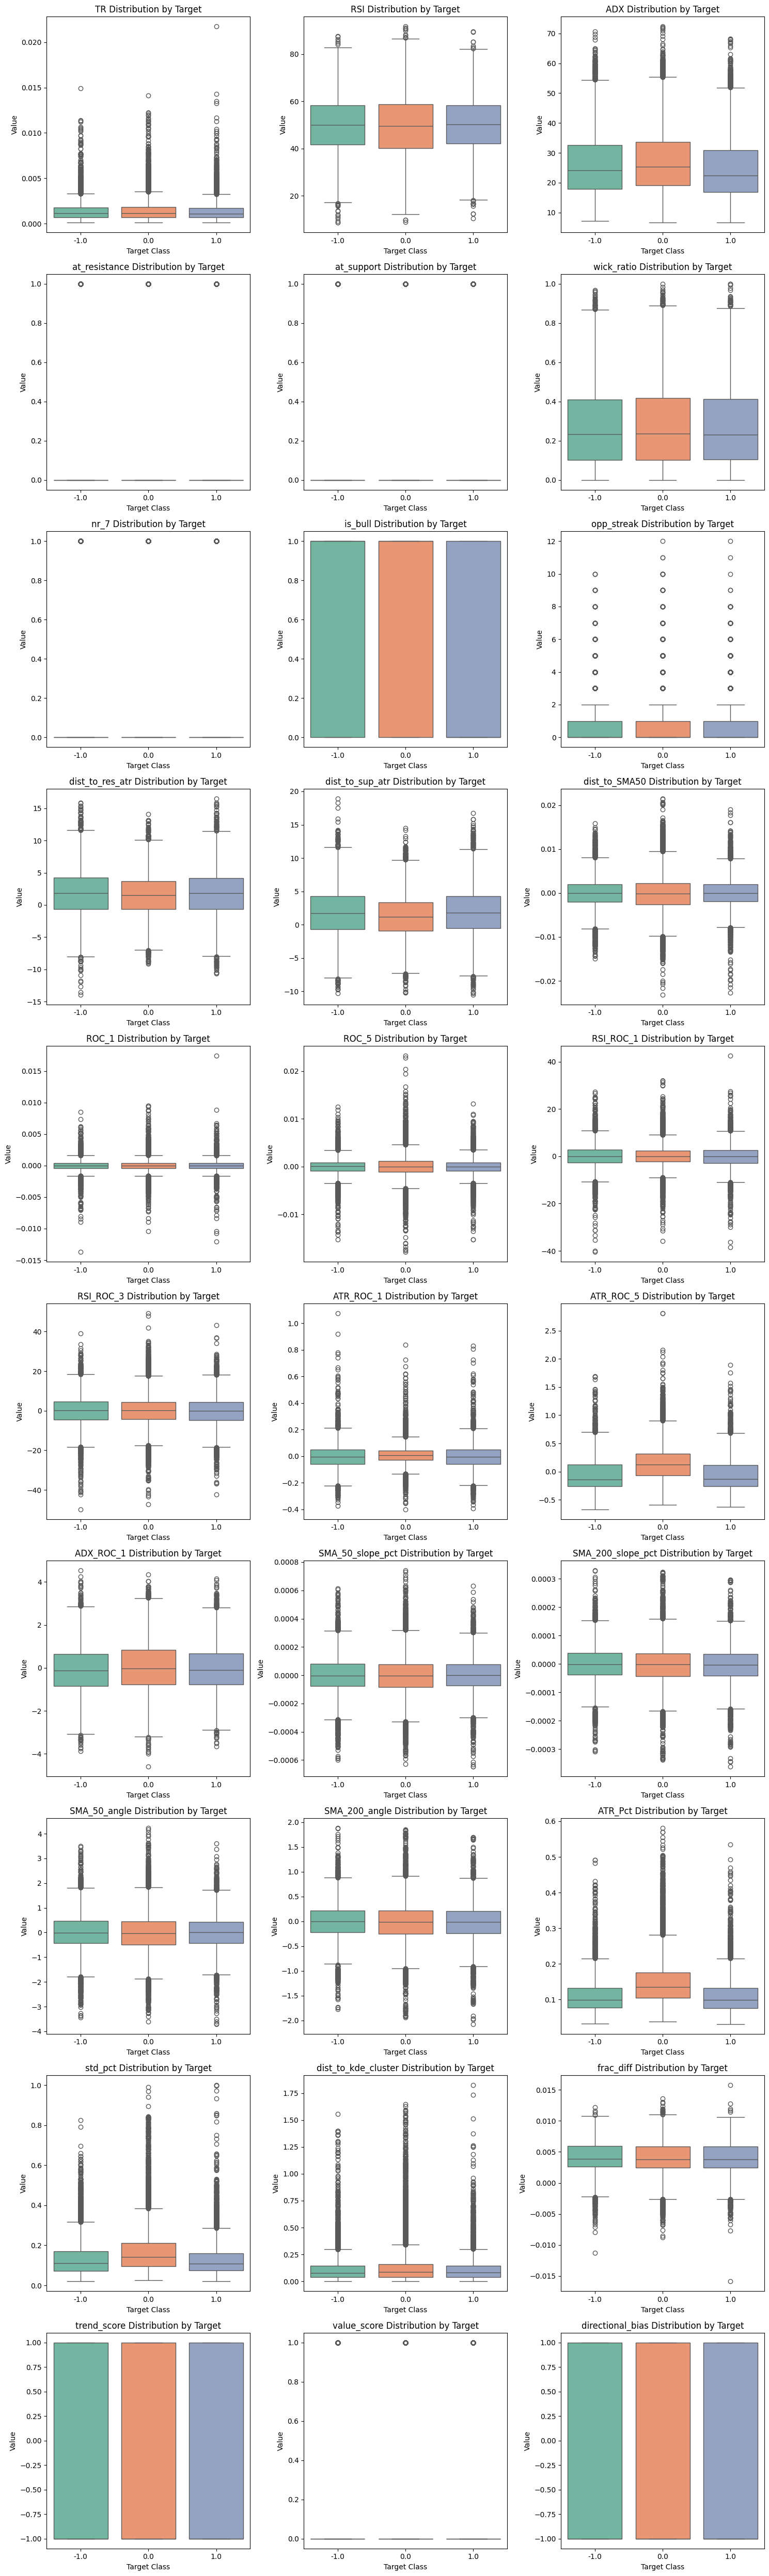

C:\Users\gui_k\AppData\Local\Temp\ipykernel_13480\2709715888.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


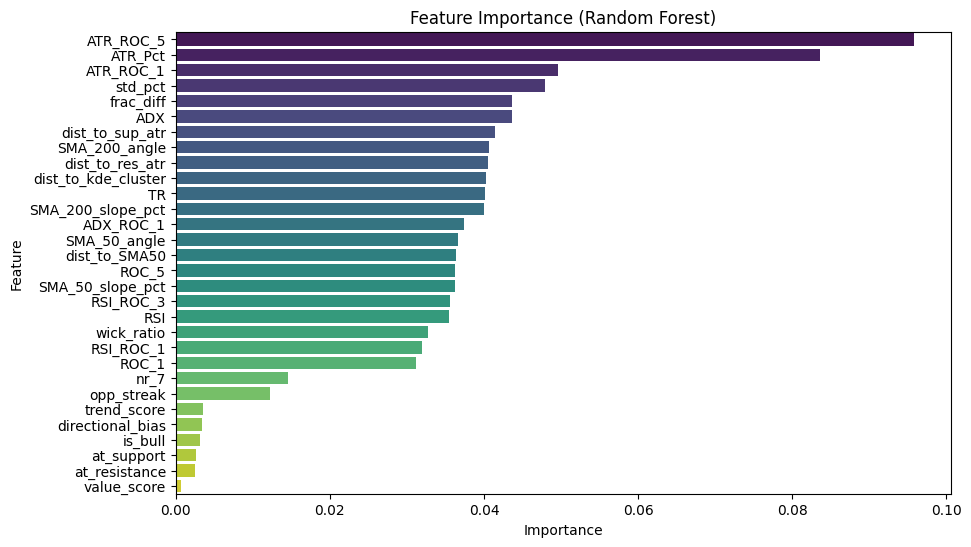

                Feature  Importance
17            ATR_ROC_5    0.095764
23              ATR_Pct    0.083648
16            ATR_ROC_1    0.049640
24              std_pct    0.047981
26            frac_diff    0.043639
2                   ADX    0.043584
10      dist_to_sup_atr    0.041443
22        SMA_200_angle    0.040673
9       dist_to_res_atr    0.040580
25  dist_to_kde_cluster    0.040201


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def analyze_feature_distributions(df, target_col='target_class'):
    """
    Plots the distribution of each feature split by target class.
    Uses Box Plots for clean comparison of medians and ranges.
    """
    # Select only numeric features (exclude target)
    feature_cols = [c for c in df.columns if c != target_col and pd.api.types.is_numeric_dtype(df[c])]
    
    # Setup the plot grid
    n_features = len(feature_cols)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()
    
    for i, feature in enumerate(feature_cols):
        # Box Plot: Shows Median (line), IQR (box), and Outliers (dots)
        sns.boxplot(x=target_col, y=feature, data=df, ax=axes[i], palette="Set2")
        axes[i].set_title(f'{feature} Distribution by Target')
        axes[i].set_xlabel('Target Class')
        axes[i].set_ylabel('Value')
        
    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

def get_feature_importance(df, target_col='target_class'):
    """
    Trains a Random Forest to quantify which features matter most.
    """
    # Prepare Data
    X = df.drop(columns=[target_col])
    y = df[target_col].astype(str) # Treat as classification
    
    # Train Model
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X, y)
    
    # Extract Importance
    importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
    plt.title('Feature Importance (Random Forest)')
    plt.show()
    
    return importances

# --- Usage ---
# Assuming 'df_clean' is your prepared dataframe
# 1. Visual Analysis

drop_list = [
    # Raw Price & Volume
    'open', 'high', 'low', 'close', 'tick_volume', 'real_volume', 'spread',
    'fair_value', 'SMA_50', 'SMA_200', 'range', 'sma',
    
    # Absolute Volatility/Residuals
    'ATR', 'std', 'residuals', 
    
    # Absolute Structure
    'avg_resistance', 'avg_support', 
    'dist_to_res', 'dist_to_sup', # Raw distance
    
    # Redundant (We prefer ATR distance over % distance)
    'dist_to_res_pct', 'dist_to_sup_pct',
    
    # Proven Useless (from your Decile Analysis)
    'efficiency_ratio',
]

df_analysis = df_clean.drop(columns=drop_list)

analyze_feature_distributions(df_analysis, target_col='target_class')

# 2. Mathematical Ranking
importance_df = get_feature_importance(df_analysis, target_col='target_class')
print(importance_df.head(10))

In [7]:
from scipy.stats import ks_2samp

def calculate_separation_score(df, feature, target_col):
    # Get values for Target=1 and Target=0 (or -1)
    group1 = df[df[target_col] == 1][feature]
    group_other = df[df[target_col] != 1][feature]
    
    stat, p_value = ks_2samp(group1, group_other)
    return stat

# Example usage
scores = {f: calculate_separation_score(df_clean, f, 'target_class') for f in df_clean.columns if f != 'target_class'}
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
print("Top features by separation:", sorted_scores[:5])

Top features by separation: [('ATR_ROC_5', np.float64(0.22086006174780787)), ('ATR', np.float64(0.2129872448370374)), ('ATR_Pct', np.float64(0.20515672810740287)), ('std', np.float64(0.13413185930971738)), ('std_pct', np.float64(0.12898462927311405))]


In [8]:
def get_decile_analysis(df, target_col='target_class', features=['ATR', 'ADX', 'std', 'efficiency_ratio']):
    """
    Breaks features into 10 bins (Deciles) and calculates the Win Rate for each bin.
    """
    # Create a copy and map target to numeric:
    # 1/-1 (Win) -> 1
    # 0 (Neutral) -> 0
    # This gives us the "Probability of a Trade"
    analysis_df = df.copy()
    analysis_df['is_valid_trade'] = analysis_df[target_col].abs()
    
    results = {}
    
    for feature in features:
        if feature not in analysis_df.columns:
            continue
            
        # Bin data into 10 equal-sized buckets (Deciles)
        try:
            analysis_df[f'{feature}_bin'] = pd.qcut(analysis_df[feature], q=10, labels=False, duplicates='drop')
            
            # Calculate Mean Win Rate per Bin
            # We group by the bin and take the average of 'is_valid_trade'
            grouped = analysis_df.groupby(f'{feature}_bin')['is_valid_trade'].mean()
            results[feature] = grouped
            
        except ValueError:
            print(f"Skipping {feature}: Not enough unique values to bin.")
            
    # Combine into a DataFrame for easy reading
    result_df = pd.DataFrame(results)
    result_df.index.name = "Decile (0=Lowest, 9=Highest)"
    return result_df

# 2. Run the Truth Table
top_features = ['ATR', 'ADX', 'std', 'efficiency_ratio', 'dist_to_kde_cluster']
truth_table = get_decile_analysis(df_analysis, target_col='target_class', features=df_analysis.columns)

print("\n--- Decile Analysis: Probability of Valid Trade by Feature Strength ---")
print(truth_table)


--- Decile Analysis: Probability of Valid Trade by Feature Strength ---
                                    TR       RSI       ADX  at_resistance  \
Decile (0=Lowest, 9=Highest)                                                
0                             0.517794  0.429080  0.636010       0.525651   
1                             0.526885  0.518782  0.575453            NaN   
2                             0.528769  0.524457  0.562682            NaN   
3                             0.530003  0.560881  0.534974            NaN   
4                             0.545572  0.558471  0.508260            NaN   
5                             0.557514  0.542098  0.490285            NaN   
6                             0.531596  0.566893  0.499514            NaN   
7                             0.533593  0.535622  0.477332            NaN   
8                             0.507194  0.542274  0.478134            NaN   
9                             0.477147  0.477979  0.493847            NaN   

  

In [18]:
def run_directional_decile_analysis(df, target_col='target_class'):
    """
    Analyzes which features predict the direction (1 vs -1) 
    specifically within the high-probability 'Quiet' regime.
    """
    # 1. Isolate the "Quiet Regime" (Bottom 30% of ATR_Pct)
    # This is where our previous analysis showed the highest edge.
    low_vol_cutoff = df['ATR_ROC_5'].quantile(0.30)
    quiet_df = df[df['ATR_ROC_5'] <= low_vol_cutoff].copy()
    
    # 2. Filter for Active Trades ONLY
    # We ignore 0 (Neutral) because we want to know: "If it moves, which way?"
    directional_df = quiet_df[quiet_df[target_col] != 0].copy()
    
    # Convert Target to Binary for calculation: 1 = Long, 0 = Short
    # This allows us to use .mean() to get the Probability of Long
    directional_df['is_long'] = (directional_df[target_col] == 1).astype(int)
    
    results = {}
    
    print(f"Analyzing {len(directional_df)} directional trades in the Quiet Regime...")
    
    for feature in df_analysis.columns:
        if feature not in directional_df.columns:
            continue
            
        # Create 10 Bins
        try:
            # We use qcut to get equal-sized groups
            directional_df[f'{feature}_bin'] = pd.qcut(
                directional_df[feature], q=10, labels=False, duplicates='drop'
            )
            
            # Calculate Probability of Long (1)
            # 0.50 means random, > 0.50 means Long bias, < 0.50 means Short bias
            grouped = directional_df.groupby(f'{feature}_bin')['is_long'].mean()
            results[feature] = grouped
            
        except ValueError:
            continue

    # 4. Display Result
    result_df = pd.DataFrame(results)
    result_df.index.name = "Decile (0=Lowest, 9=Highest)"
    
    print("\n--- Directional Probabilities (0.50 = Random) ---")
    print("Values > 0.60 = Strong Long Trigger | Values < 0.40 = Strong Short Trigger")
    return result_df

# Execute the analysis
directional_table = run_directional_decile_analysis(df_clean)
print(directional_table)

Analyzing 7348 directional trades in the Quiet Regime...

--- Directional Probabilities (0.50 = Random) ---
Values > 0.60 = Strong Long Trigger | Values < 0.40 = Strong Short Trigger
                                    TR       RSI       ADX  at_resistance  \
Decile (0=Lowest, 9=Highest)                                                
0                             0.497347  0.491156  0.542857       0.488432   
1                             0.496533  0.473469  0.561905            NaN   
2                             0.515915  0.457143  0.510204            NaN   
3                             0.463382  0.486376  0.500000            NaN   
4                             0.482667  0.519728  0.480272            NaN   
5                             0.484594  0.496599  0.448980            NaN   
6                             0.470672  0.495913  0.463215            NaN   
7                             0.487179  0.502041  0.435374            NaN   
8                             0.505479  0.47483

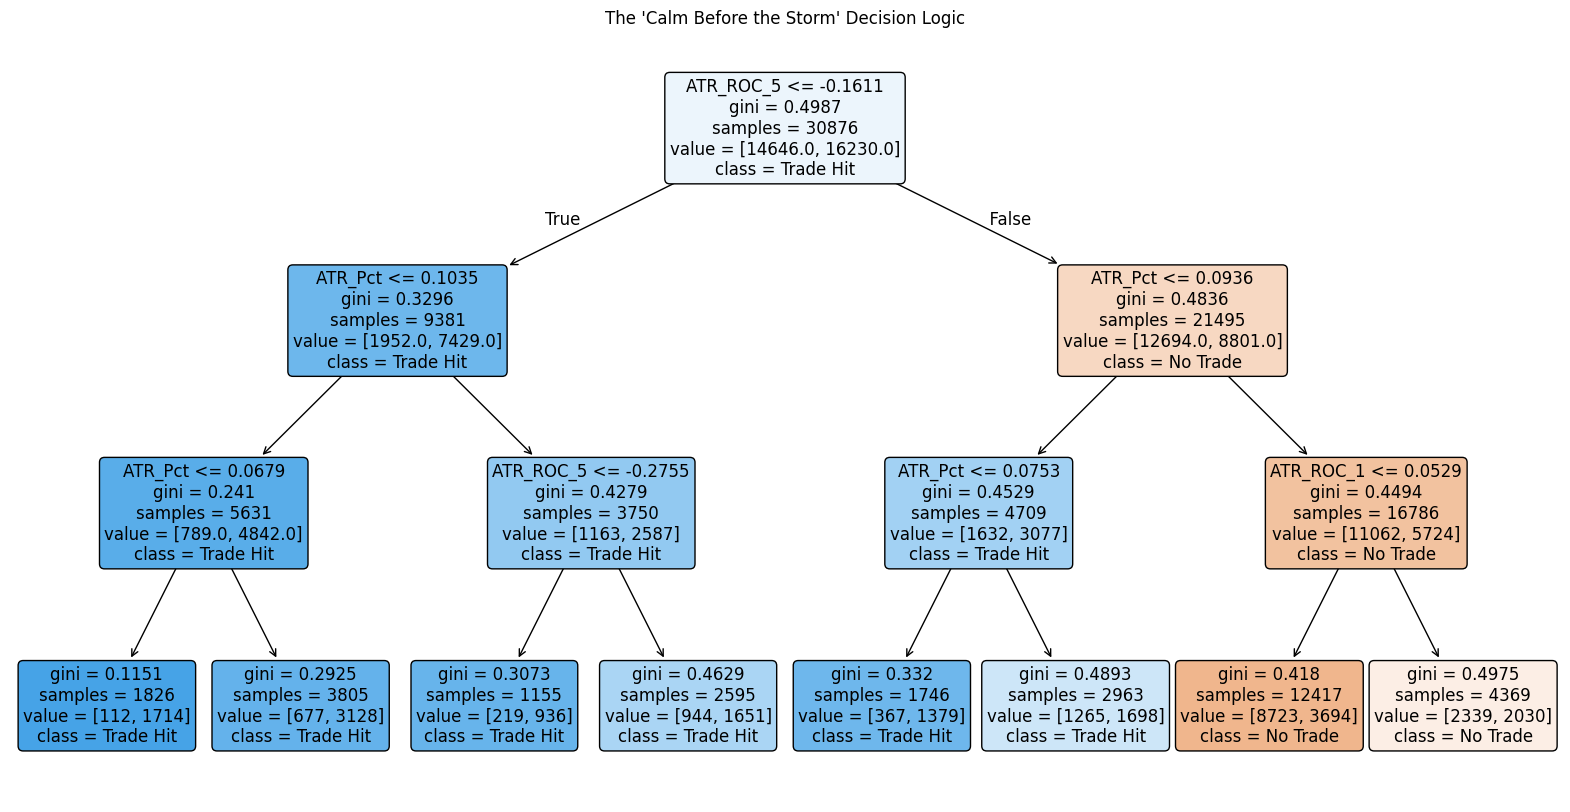

In [10]:

def generate_trading_rules(df, target_col='target_class'):
    # 1. Select only the features that showed a strong gradient in Decile Analysis
    top_features = [
        'ATR_ROC_5', 'ATR_Pct', 'std_pct', 'ADX', 'frac_diff', 'SMA_200_angle', 'SMA_200_slope_pct', 'dist_to_kde_cluster', 'ATR_ROC_1'
    ]
    
    # 2. Prepare Data (Valid trades only vs Neutral)
    # We want to see what triggers a MOVE (1 or -1) vs NO MOVE (0)
    df_rules = df.copy()
    df_rules['event'] = df_rules[target_col].abs()
    
    X = df_rules[top_features].dropna()
    y = df_rules.loc[X.index, 'event']
    
    # 3. Train a "Shallow" Tree to extract human-readable rules
    clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100)
    clf.fit(X, y)
    
    # 4. Plot the Rule Map
    plt.figure(figsize=(20, 10))
    plot_tree(clf, 
              feature_names=top_features, 
              class_names=['No Trade', 'Trade Hit'], 
              filled=True, 
              rounded=True, 
              fontsize=12,
              precision=4)
    plt.title("The 'Calm Before the Storm' Decision Logic")
    plt.show()

# Run it
generate_trading_rules(df_clean)

Backtest

In [11]:
def generate_final_signals(df):
    """
    Combines Volatility Squeeze with Order Flow Direction.
    """
    # 1. Define our thresholds based on your Decile Analysis
    # These 'Magic Numbers' come from your previous outputs
    low_vol_threshold = df['ATR_Pct'].quantile(0.30)
    ofi_threshold = 0.2 # Adjust based on your OFI_norm distribution
    
    df['final_signal'] = 0
    
    # --- LONG CONDITION ---
    # Quiet + Buying Pressure + Bullish Trend
    long_mask = (
        (df['ATR_Pct'] <= low_vol_threshold) & 
        (df['OFI_norm'] > ofi_threshold) & 
        (df['SMA_200_angle'] > 0)
    )
    
    # --- SHORT CONDITION ---
    # Quiet + Selling Pressure + Bearish Trend
    short_mask = (
        (df['ATR_Pct'] <= low_vol_threshold) & 
        (df['OFI_norm'] < -ofi_threshold) & 
        (df['SMA_200_angle'] < 0)
    )
    
    df.loc[long_mask, 'final_signal'] = 1
    df.loc[short_mask, 'final_signal'] = -1
    
    return df

def generate_hybrid_signals(df):
    """
    Direction is decided by Mean Reversion (dist_to_SMA50).
    Entry is decided by Volatility (ATR_Pct).
    """
    # 1. Thresholds from your successful analyses
    low_vol_cutoff = df['ATR_Pct'].quantile(0.30)
    
    # 2. Logic
    df['final_signal'] = 0
    
    # LONG: Quiet + Price significantly below the 50-SMA (Decile 0 probability = 0.59)
    long_mask = (df['ATR_Pct'] <= low_vol_cutoff) & (df['dist_to_SMA50'] < df['dist_to_SMA50'].quantile(0.10))
    
    # SHORT: Quiet + Price significantly above the 50-SMA
    short_mask = (df['ATR_Pct'] <= low_vol_cutoff) & (df['dist_to_SMA50'] > df['dist_to_SMA50'].quantile(0.90))
    
    df.loc[long_mask, 'final_signal'] = 1
    df.loc[short_mask, 'final_signal'] = -1
    
    return df

def generate_filtered_hybrid_signals(df):
    """
    Direction: Mean Reversion (dist_to_SMA50)
    Regime: Volatility (ATR_Pct)
    Gate: Time of Day (Golden Hours)
    """
    # 1. Thresholds
    low_vol_cutoff = df['ATR_Pct'].quantile(0.30)
    
    # 2. Define Golden Hours (04:00 - 13:00)
    # We use a list or range of hours that showed > 40% win rate
    golden_hours = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15] 
    
    df['final_signal'] = 0
    df['hour'] = df.index.hour
    
    # 3. Apply Conditions
    # We add (df['hour'].isin(golden_hours)) as a mandatory filter
    long_mask = (
        (df['ATR_Pct'] <= low_vol_cutoff) & 
        (df['dist_to_SMA50'] < df['dist_to_SMA50'].quantile(0.10)) &
        (df['hour'].isin(golden_hours))
    )
    
    short_mask = (
        (df['ATR_Pct'] <= low_vol_cutoff) & 
        (df['dist_to_SMA50'] > df['dist_to_SMA50'].quantile(0.90)) &
        (df['hour'].isin(golden_hours))
    )
    
    df.loc[long_mask, 'final_signal'] = 1
    df.loc[short_mask, 'final_signal'] = -1
    
    return df

def generate_unbiased_signals(df, lookback=500):
    """
    Direction: Mean Reversion (dist_to_SMA50)
    Regime: Volatility (ATR_Pct)
    Gate: Time of Day (Golden Hours)
    
    FIXED: Variables synced and look-ahead bias removed.
    """
    # 1. Calculate ROLLING thresholds (No look-ahead)
    # We use a lookback (e.g., 500 bars) to determine what 'low' means currently
    df['vol_threshold'] = df['ATR_Pct'].rolling(window=lookback).quantile(0.30)
    df['dist_low_threshold'] = df['dist_to_SMA50'].rolling(window=lookback).quantile(0.10)
    df['dist_high_threshold'] = df['dist_to_SMA50'].rolling(window=lookback).quantile(0.90)
    
    # 2. Golden Hours (A Priori rule)
    golden_hours = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]
    df['hour'] = df.index.hour
    
    # Initialize signal column
    df['final_signal'] = 0
    
    # 3. Apply Conditions using SHIFTED thresholds
    # We use .shift(1) to ensure we only use data known BEFORE the current bar
    long_mask = (
        (df['ATR_Pct'] <= df['vol_threshold'].shift(1)) & 
        (df['dist_to_SMA50'] < df['dist_low_threshold'].shift(1)) &
        (df['hour'].isin(golden_hours))
    )
    
    short_mask = (
        (df['ATR_Pct'] <= df['vol_threshold'].shift(1)) & 
        (df['dist_to_SMA50'] > df['dist_high_threshold'].shift(1)) &
        (df['hour'].isin(golden_hours))
    )
    
    df.loc[long_mask, 'final_signal'] = 1
    df.loc[short_mask, 'final_signal'] = -1
    
    # Cleanup: Drop the 'warm-up' rows where the rolling window hadn't finished
    return df.dropna(subset=['vol_threshold'])

df_signal = df_clean.copy()
# 2. Generate the Signals (The "Guess")
# df_signal = generate_final_signals(df_signal)
# df_signal = generate_hybrid_signals(df_signal)
# df_signal = generate_filtered_hybrid_signals(df_signal)
df_signal = generate_unbiased_signals(df_signal, lookback=500)


# 3. ANALYSIS: How often does our signal lead to a win?
# Create a filter for rows where we actually generated a signal
active_signals = df_signal[df_signal['final_signal'] != 0].copy()

# Calculate the Win Rate
# A 'Win' is when final_signal matches target_class
active_signals['is_correct'] = (active_signals['final_signal'] == active_signals['target_class'])

win_rate = active_signals['is_correct'].mean() * 100
total_trades = len(active_signals)

print(f"--- Strategy Backtest Results ---")
print(f"Total Signals Generated: {total_trades}")
print(f"Accuracy (Win Rate): {win_rate:.2f}%")

# Break down by direction
longs = active_signals[active_signals['final_signal'] == 1]
shorts = active_signals[active_signals['final_signal'] == -1]

print(f"Long Win Rate: {(longs['target_class'] == 1).mean()*100:.2f}%")
print(f"Short Win Rate: {(shorts['target_class'] == -1).mean()*100:.2f}%")

--- Strategy Backtest Results ---
Total Signals Generated: 837
Accuracy (Win Rate): 45.52%
Long Win Rate: 43.94%
Short Win Rate: 46.94%


--- Win Rate by Hour (SGT/Server Time) ---
hour
4     0.545455
5     0.500000
6     0.526316
7     0.521739
8     0.447368
9     0.512821
10    0.431193
11    0.383838
12    0.367816
13    0.441176
15    0.363636
Name: is_correct, dtype: float64


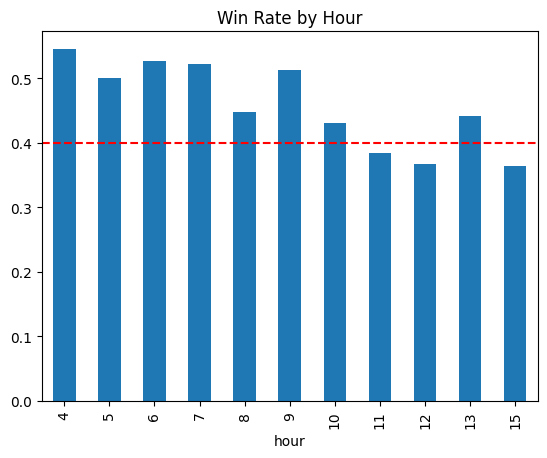

In [12]:
# Check performance by hour to find your 'Golden Window'
active_signals['hour'] = active_signals.index.hour
hourly_win_rate = active_signals.groupby('hour')['is_correct'].mean()

print("--- Win Rate by Hour (SGT/Server Time) ---")
print(hourly_win_rate)

hourly_win_rate.plot(kind='bar', title='Win Rate by Hour')
plt.axhline(y=0.40, color='r', linestyle='--') # 40% target line
plt.show()

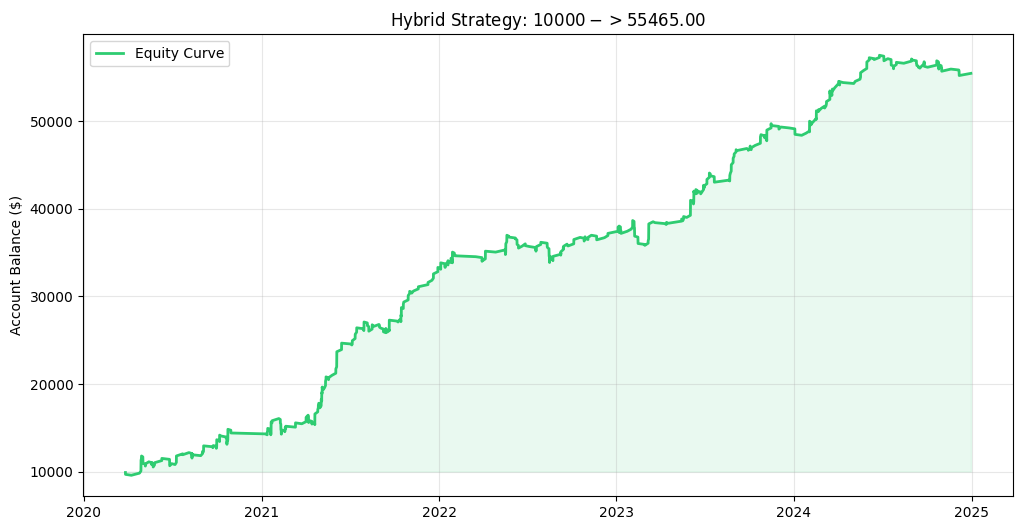

--- Portfolio Stats ---
Total Profit: $45465.00
Profit Factor: 1.95
Max Drawdown: $3115.00
Return on Initial Capital: 454.65%


In [13]:
import matplotlib.pyplot as plt

def plot_backtest_results(df, initial_balance=10000, risk_per_trade=100):
    trades = df[df['final_signal'] != 0].copy()
    
    # ESTIMATE SPREAD COST
    # Assuming 1 pip spread on EURUSD (approx $10 per lot, scaled to your risk)
    # If risk is $100, a standard lot size is approx 0.1-0.2 lots. 
    # Let's approximate spread cost as 5% of risk per trade (conservative).
    spread_cost = risk_per_trade * 0.05 
    
    trades['pnl'] = np.where(
        trades['final_signal'] == trades['target_class'], 
        (risk_per_trade * 2.5) - spread_cost,  # Win minus spread
        -risk_per_trade - spread_cost          # Loss minus spread
    )
    
    # 3. Calculate Cumulative Equity
    trades['equity'] = initial_balance + trades['pnl'].cumsum()
    
    # 4. Performance Metrics
    total_profit = trades['pnl'].sum()
    profit_factor = trades[trades['pnl'] > 0]['pnl'].sum() / abs(trades[trades['pnl'] < 0]['pnl'].sum())
    max_drawdown = (trades['equity'].cummax() - trades['equity']).max()
    
    # 5. Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(trades.index, trades['equity'], label='Equity Curve', color='#2ecc71', lw=2)
    plt.fill_between(trades.index, initial_balance, trades['equity'], alpha=0.1, color='#2ecc71')
    plt.title(f"Hybrid Strategy: ${initial_balance} -> ${trades['equity'].iloc[-1]:.2f}")
    plt.ylabel("Account Balance ($)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print(f"--- Portfolio Stats ---")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Profit Factor: {profit_factor:.2f}")
    print(f"Max Drawdown: ${max_drawdown:.2f}")
    print(f"Return on Initial Capital: {(total_profit/initial_balance)*100:.2f}%")

# --- HOW TO USE THIS ---
# Simply pass your processed dataframe to the function
plot_backtest_results(df_signal)

In [14]:
df_signal[['ATR_Pct', 'vol_threshold', 'dist_to_SMA50', 'close']].loc['2022-02-03 14:00:00']

ATR_Pct          0.094638
vol_threshold    0.089511
dist_to_SMA50    0.000499
close            1.129120
Name: 2022-02-03 14:00:00, dtype: float64

In [ ]:
   // --- 7. EXECUTION ---
   if(signal) {
      double atr = buf_atr[cur];
      double entry = atr * InpEntryATRMult;
      double sl    = atr * InpSLATRMult;
      double tp    = atr * InpTPATRMult;
      
      double buy_pt = buf_close[cur] + entry;
      double sell_pt = buf_close[cur] - entry;
      datetime exp = TimeCurrent() + (InpOrderExpireHours * 3600);
      
      trade.BuyStop(GetLotSize(sl), buy_pt, _Symbol, 
         NormalizeDouble(buy_pt - sl, _Digits), NormalizeDouble(buy_pt + tp, _Digits), 
         ORDER_TIME_SPECIFIED, exp, "Quant Buy");
         
      trade.SellStop(GetLotSize(sl), sell_pt, _Symbol, 
         NormalizeDouble(sell_pt + sl, _Digits), NormalizeDouble(sell_pt - tp, _Digits), 
         ORDER_TIME_SPECIFIED, exp, "Quant Sell");
   }
   
   
   
   // --- 7. EXECUTION (MEAN REVERSION / FADE) ---
   
   //if(signal) {
   //   double atr = buf_atr[cur];
   //   double entry_dist = atr * InpEntryATRMult; // How far to let it spike before fading
   //   double sl_dist    = atr * InpSLATRMult;
   //   double tp_dist    = atr * InpTPATRMult;
   //   
   //   // Calculate the "Fade" Levels
   //   double upper_level = buf_close[cur] + entry_dist; // We Sell here
   //   double lower_level = buf_close[cur] - entry_dist; // We Buy here
   //   
   //   datetime exp = TimeCurrent() + (InpOrderExpireHours * 3600);
   //   
   //   // 1. Place SELL LIMIT at the Top (Betting against the rally)
   //   // SL is ABOVE entry, TP is BELOW entry (returning to mean)
   //   double sell_sl = upper_level + sl_dist;
   //   double sell_tp = upper_level - tp_dist;
   //   
   //   trade.SellLimit(GetLotSize(sl_dist), upper_level, _Symbol, 
   //      NormalizeDouble(sell_sl, _Digits), 
   //      NormalizeDouble(sell_tp, _Digits), 
   //      ORDER_TIME_SPECIFIED, exp, "Quant Fade Short");
   //      
   //   // 2. Place BUY LIMIT at the Bottom (Betting against the dip)
   //   // SL is BELOW entry, TP is ABOVE entry (returning to mean)
   //   double buy_sl = lower_level - sl_dist;
   //   double buy_tp = lower_level + tp_dist;
   //   
   //   trade.BuyLimit(GetLotSize(sl_dist), lower_level, _Symbol, 
   //      NormalizeDouble(buy_sl, _Digits), 
   //      NormalizeDouble(buy_tp, _Digits), 
   //      ORDER_TIME_SPECIFIED, exp, "Quant Fade Long");
   //      
   //   if(InpDebugMode) PrintFormat("PLACED FADE ORDERS | BuyLimit: %.5f | SellLimit: %.5f", lower_level, upper_level);
   //}